<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/%20Chapter-8-Generalized_Solutions/Untitled184.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Learning Continuous Linear Functionals on $C([0,1])$**

We consider the continuous linear functional
$
F:C([0,1])\rightarrow \mathbb{R}
$
defined by
$$
F(f)
=
\int_0^1 f(t)e^t\,dt
+
3f(0.75),
$$
which corresponds to the measure
$$
dg(t)
=
e^t\,dt
+
3\delta_{0.75}.
$$

We generate synthetic measurements
$
F_k=F(f_k)$,
$
f_k(t)=t^k$,
$
1\le k\le 50$, and then recover the measure.


Synthetic data F_k:
k= 1, F_k=3.25000000
k= 2, F_k=2.40578183
k= 3, F_k=1.82906134
k= 4, F_k=1.41375521
k= 5, F_k=1.10751361
k= 6, F_k=0.87862009
k= 7, F_k=0.70594170
k= 8, F_k=0.57470028
k= 9, F_k=0.47428209
k=10, F_k=0.39694206
k=11, F_k=0.33697057
k=12, F_k=0.29012899
k=13, F_k=0.25325452
k=14, F_k=0.22397755
k=15, F_k=0.20051669
k=16, F_k=0.18152867
k=17, F_k=0.16599761
k=18, F_k=0.15315302
k=19, F_k=0.14240875
k=20, F_k=0.13331747
k=21, F_k=0.12553661
k=22, F_k=0.11880283
k=23, F_k=0.11291286
k=24, F_k=0.10770902
k=25, F_k=0.10306841
k=26, F_k=0.09889470
k=27, F_k=0.09511187
k=28, F_k=0.09165956
k=29, F_k=0.08848949
k=30, F_k=0.08556272
k=31, F_k=0.08284759
k=32, F_k=0.08031817
k=33, F_k=0.07795299
k=34, F_k=0.07573415
k=35, F_k=0.07364657
k=36, F_k=0.07167745
k=37, F_k=0.06981581
k=38, F_k=0.06805219
k=39, F_k=0.06637835
k=40, F_k=0.06478706
k=41, F_k=0.06327195
k=42, F_k=0.06182735
k=43, F_k=0.06044821
k=44, F_k=0.05913000
k=45, F_k=0.05786861
k=46, F_k=0.05666035
k=47, F_k=0.05

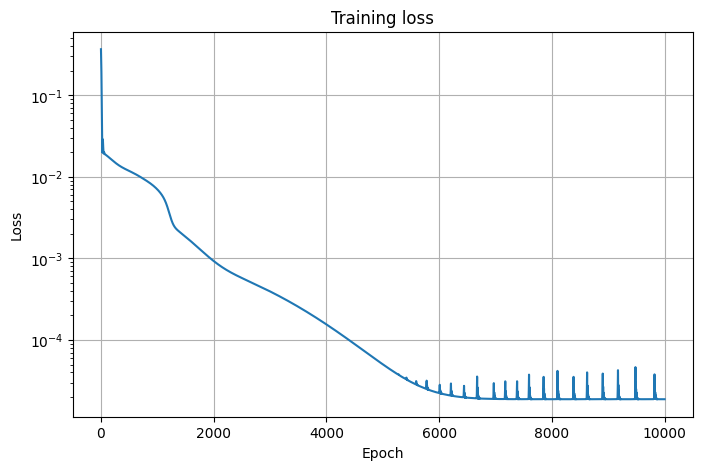

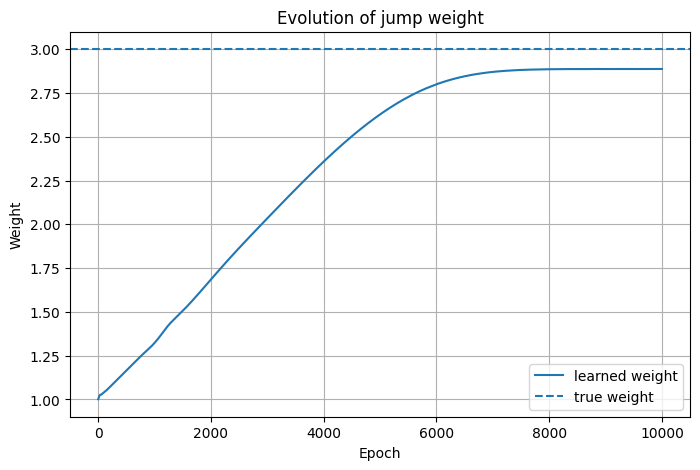

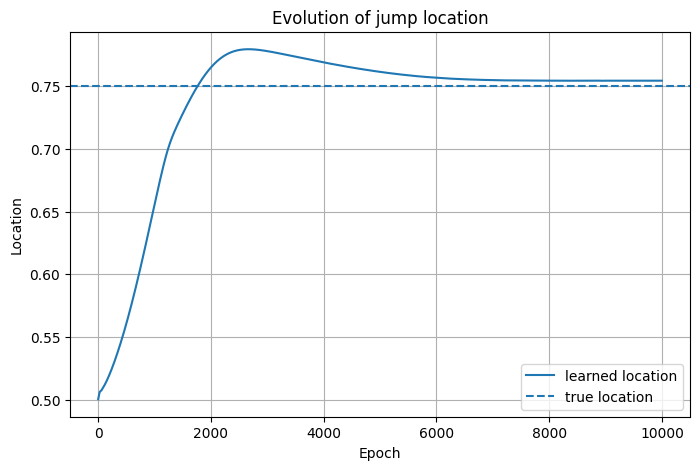

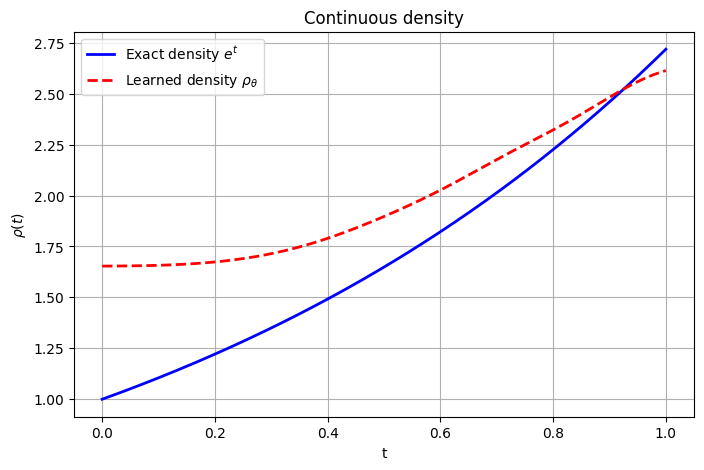


Final learned parameters:
Learned atom weight = 2.887188
Learned atom location = 0.75437725


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.integrate import quad

# =========================
# Synthetic data
# =========================
K = 50
ks = np.arange(1, K+1)

# TRUE atom parameters
TRUE_WEIGHT = 3.0
TRUE_LOCATION = 0.75

def true_F(k):
    integral, _ = quad(lambda t: (t**k)*np.exp(t), 0, 1)
    atom = TRUE_WEIGHT * (TRUE_LOCATION**k)
    return integral + atom

F_data_np = np.array([true_F(k) for k in ks]).reshape(-1,1)

print("Synthetic data F_k:")
for k, val in zip(ks, F_data_np.flatten()):
    print(f"k={k:2d}, F_k={val:.8f}")

F_data = tf.constant(F_data_np, dtype=tf.float32)
ks_tf = tf.constant(ks.reshape(-1,1), dtype=tf.float32)

# =========================
# Quadrature grid
# =========================
N_quad = 10000

t_np = np.linspace(0, 1, N_quad).reshape(-1,1)
t_tf = tf.constant(t_np, dtype=tf.float32)

dt = 1.0 / (N_quad - 1)

# basis functions t^k
basis_np = np.array([(t_np.flatten()**k) for k in ks])
basis_tf = tf.constant(basis_np, dtype=tf.float32)

# trapezoidal weights
weights = np.ones(N_quad)
weights[0] = 0.5
weights[-1] = 0.5
weights_tf = tf.constant(weights, dtype=tf.float32)

# =========================
# Neural density model
# =========================
def build_density_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(1,)),
        tf.keras.layers.Dense(64, activation='tanh'),
        tf.keras.layers.Dense(64, activation='tanh'),
        tf.keras.layers.Dense(64, activation='tanh'),
        tf.keras.layers.Dense(1)
    ])

rho_model = build_density_model()

# =========================
# Trainable atom parameters
# =========================
a_raw = tf.Variable(1.0, dtype=tf.float32)

# unconstrained variable
x_raw = tf.Variable(0.0, dtype=tf.float32)

def atom_location():
    # maps to interval (0,1)
    return tf.sigmoid(x_raw)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

# =========================
# Prediction
# =========================
def compute_predictions():

    rho_vals = rho_model(t_tf)[:,0]

    # integral part
    integral_part = dt * tf.reduce_sum(
        basis_tf * rho_vals[None,:] * weights_tf[None,:],
        axis=1,
        keepdims=True
    )

    # atomic part
    x_atom = atom_location()

    atom_part = a_raw * tf.pow(x_atom, ks_tf)

    return integral_part + atom_part

# =========================
# Loss
# =========================
def compute_loss():

    F_pred = compute_predictions()

    data_loss = tf.reduce_mean(
        tf.square(F_pred - F_data)
    )

    # smoothness regularization
    with tf.GradientTape() as tape:
        tape.watch(t_tf)
        rho_vals = rho_model(t_tf)

    rho_t = tape.gradient(rho_vals, t_tf)

    smooth_loss = tf.reduce_mean(tf.square(rho_t))

    total_loss = data_loss + 1e-5 * smooth_loss

    return total_loss, data_loss

# =========================
# Training
# =========================
EPOCHS = 10000

loss_history = []
a_history = []
x_history = []

for epoch in range(EPOCHS):

    with tf.GradientTape() as tape:

        loss, data_loss = compute_loss()

    variables = (
        rho_model.trainable_variables
        + [a_raw, x_raw]
    )

    grads = tape.gradient(loss, variables)

    optimizer.apply_gradients(
        zip(grads, variables)
    )

    loss_history.append(loss.numpy().item())
    a_history.append(a_raw.numpy().item())
    x_history.append(atom_location().numpy().item())

    if epoch % 1000 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Loss={loss.numpy().item():.6e} | "
            f"a={a_raw.numpy().item():.6f} | "
            f"x={atom_location().numpy().item():.6f}"
        )

# =========================
# Plot loss
# =========================
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.grid()
plt.show()

# =========================
# Plot atom weight evolution
# =========================
plt.figure(figsize=(8,5))

plt.plot(a_history, label="learned weight")

plt.axhline(
    TRUE_WEIGHT,
    linestyle='--',
    label='true weight'
)

plt.xlabel("Epoch")
plt.ylabel("Weight")
plt.title("Evolution of jump weight")
plt.legend()
plt.grid()
plt.show()

# =========================
# Plot atom location evolution
# =========================
plt.figure(figsize=(8,5))

plt.plot(x_history, label="learned location")

plt.axhline(
    TRUE_LOCATION,
    linestyle='--',
    label='true location'
)

plt.xlabel("Epoch")
plt.ylabel("Location")
plt.title("Evolution of jump location")
plt.legend()
plt.grid()
plt.show()

# =========================
# Plot density
# =========================
rho_learned = rho_model(t_tf).numpy().flatten()

rho_exact = np.exp(t_np.flatten())

plt.figure(figsize=(8,5))

plt.plot(
    t_np,
    rho_exact,
    'b-',
    linewidth=2,
    label=r'Exact density $e^t$'
)

plt.plot(
    t_np,
    rho_learned,
    'r--',
    linewidth=2,
    label=r'Learned density $\rho_\theta$'
)

plt.xlabel("t")
plt.ylabel(r"$\rho(t)$")
plt.title("Continuous density")
plt.legend()
plt.grid()
plt.show()

# =========================
# Final learned parameters
# =========================
print("\nFinal learned parameters:")
print("Learned atom weight =", a_raw.numpy())
print("Learned atom location =", atom_location().numpy())